# Feature Selection

Appliquer la PCA pour visualiser les données. Calculer les corrélations entre features. Supprimer les features redondantes. Livrable : notebook feature_selection.ipynb.


## Importation des librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler  # normalisation des données
from sklearn.decomposition import PCA             # réduction de dimension


In [2]:
chemin_CICIDS = '../Data/cicids_clean.csv'
chemin_UNSW   = '../Data/unsw_clean.csv'
chemin_LOGS   = '../Data/logs_clean.csv'

df_cicids = pd.read_csv(chemin_CICIDS, low_memory=False)
df_unsw   = pd.read_csv(chemin_UNSW,   low_memory=False)
df_logs   = pd.read_csv(chemin_LOGS,   low_memory=False)


## Dataset 1 : CIC-IDS-2017

### 1.1 Sélection des features numériques

On garde que les colonnes numériques pour la PCA et les corrélations 

In [3]:
features_cicids = df_cicids.select_dtypes(include=[np.number]).columns.tolist() #garder uniquement les colonnes qui contiennent des nombres (int ou float)
print(f"Nombre de features numériques : {len(features_cicids)}")
print(features_cicids)

Nombre de features numériques : 79
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count'

### 1.2 Matrice de corrélation

La corrélation permet de mesurer à quel point deux features évoluent ensemble aisni une corrélation proche de 1 ou -1 signifie que les deux features donnent la même information.

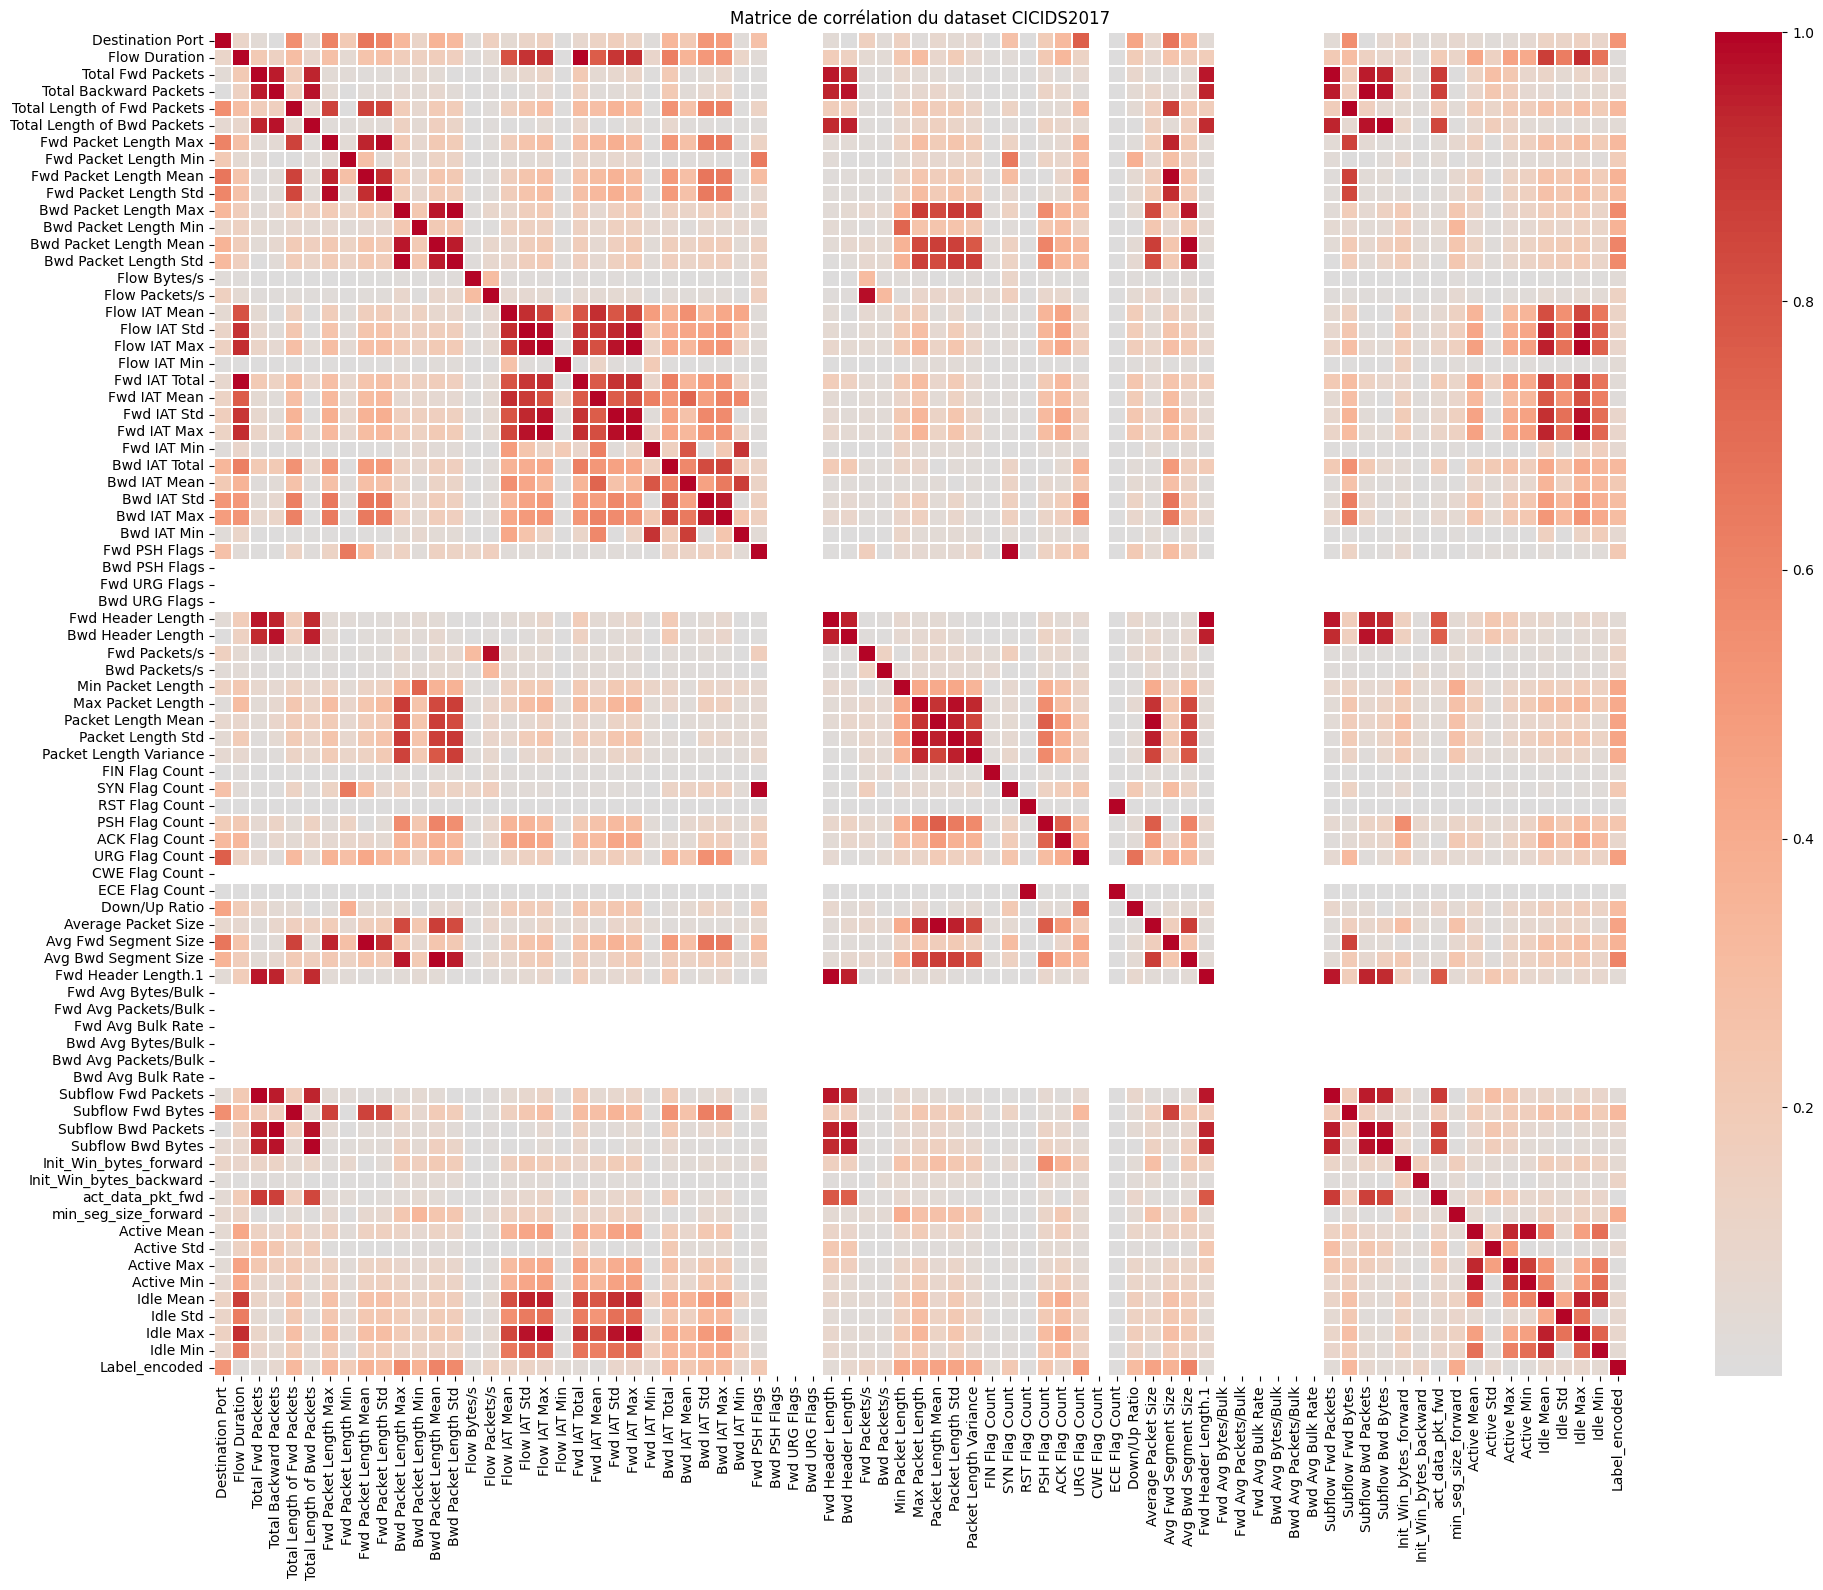

In [4]:
corr_cicids = df_cicids[features_cicids].corr().abs()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_cicids, cmap='coolwarm', center=0, linewidths=0.1)
plt.title('Matrice de corrélation du dataset CICIDS2017')
plt.tight_layout()
plt.savefig('../Data/corr_cicids.png', dpi=100)
plt.show()

Maintenant on ne va que afficher les corrélations dites fortes donc supérieures à 0.7

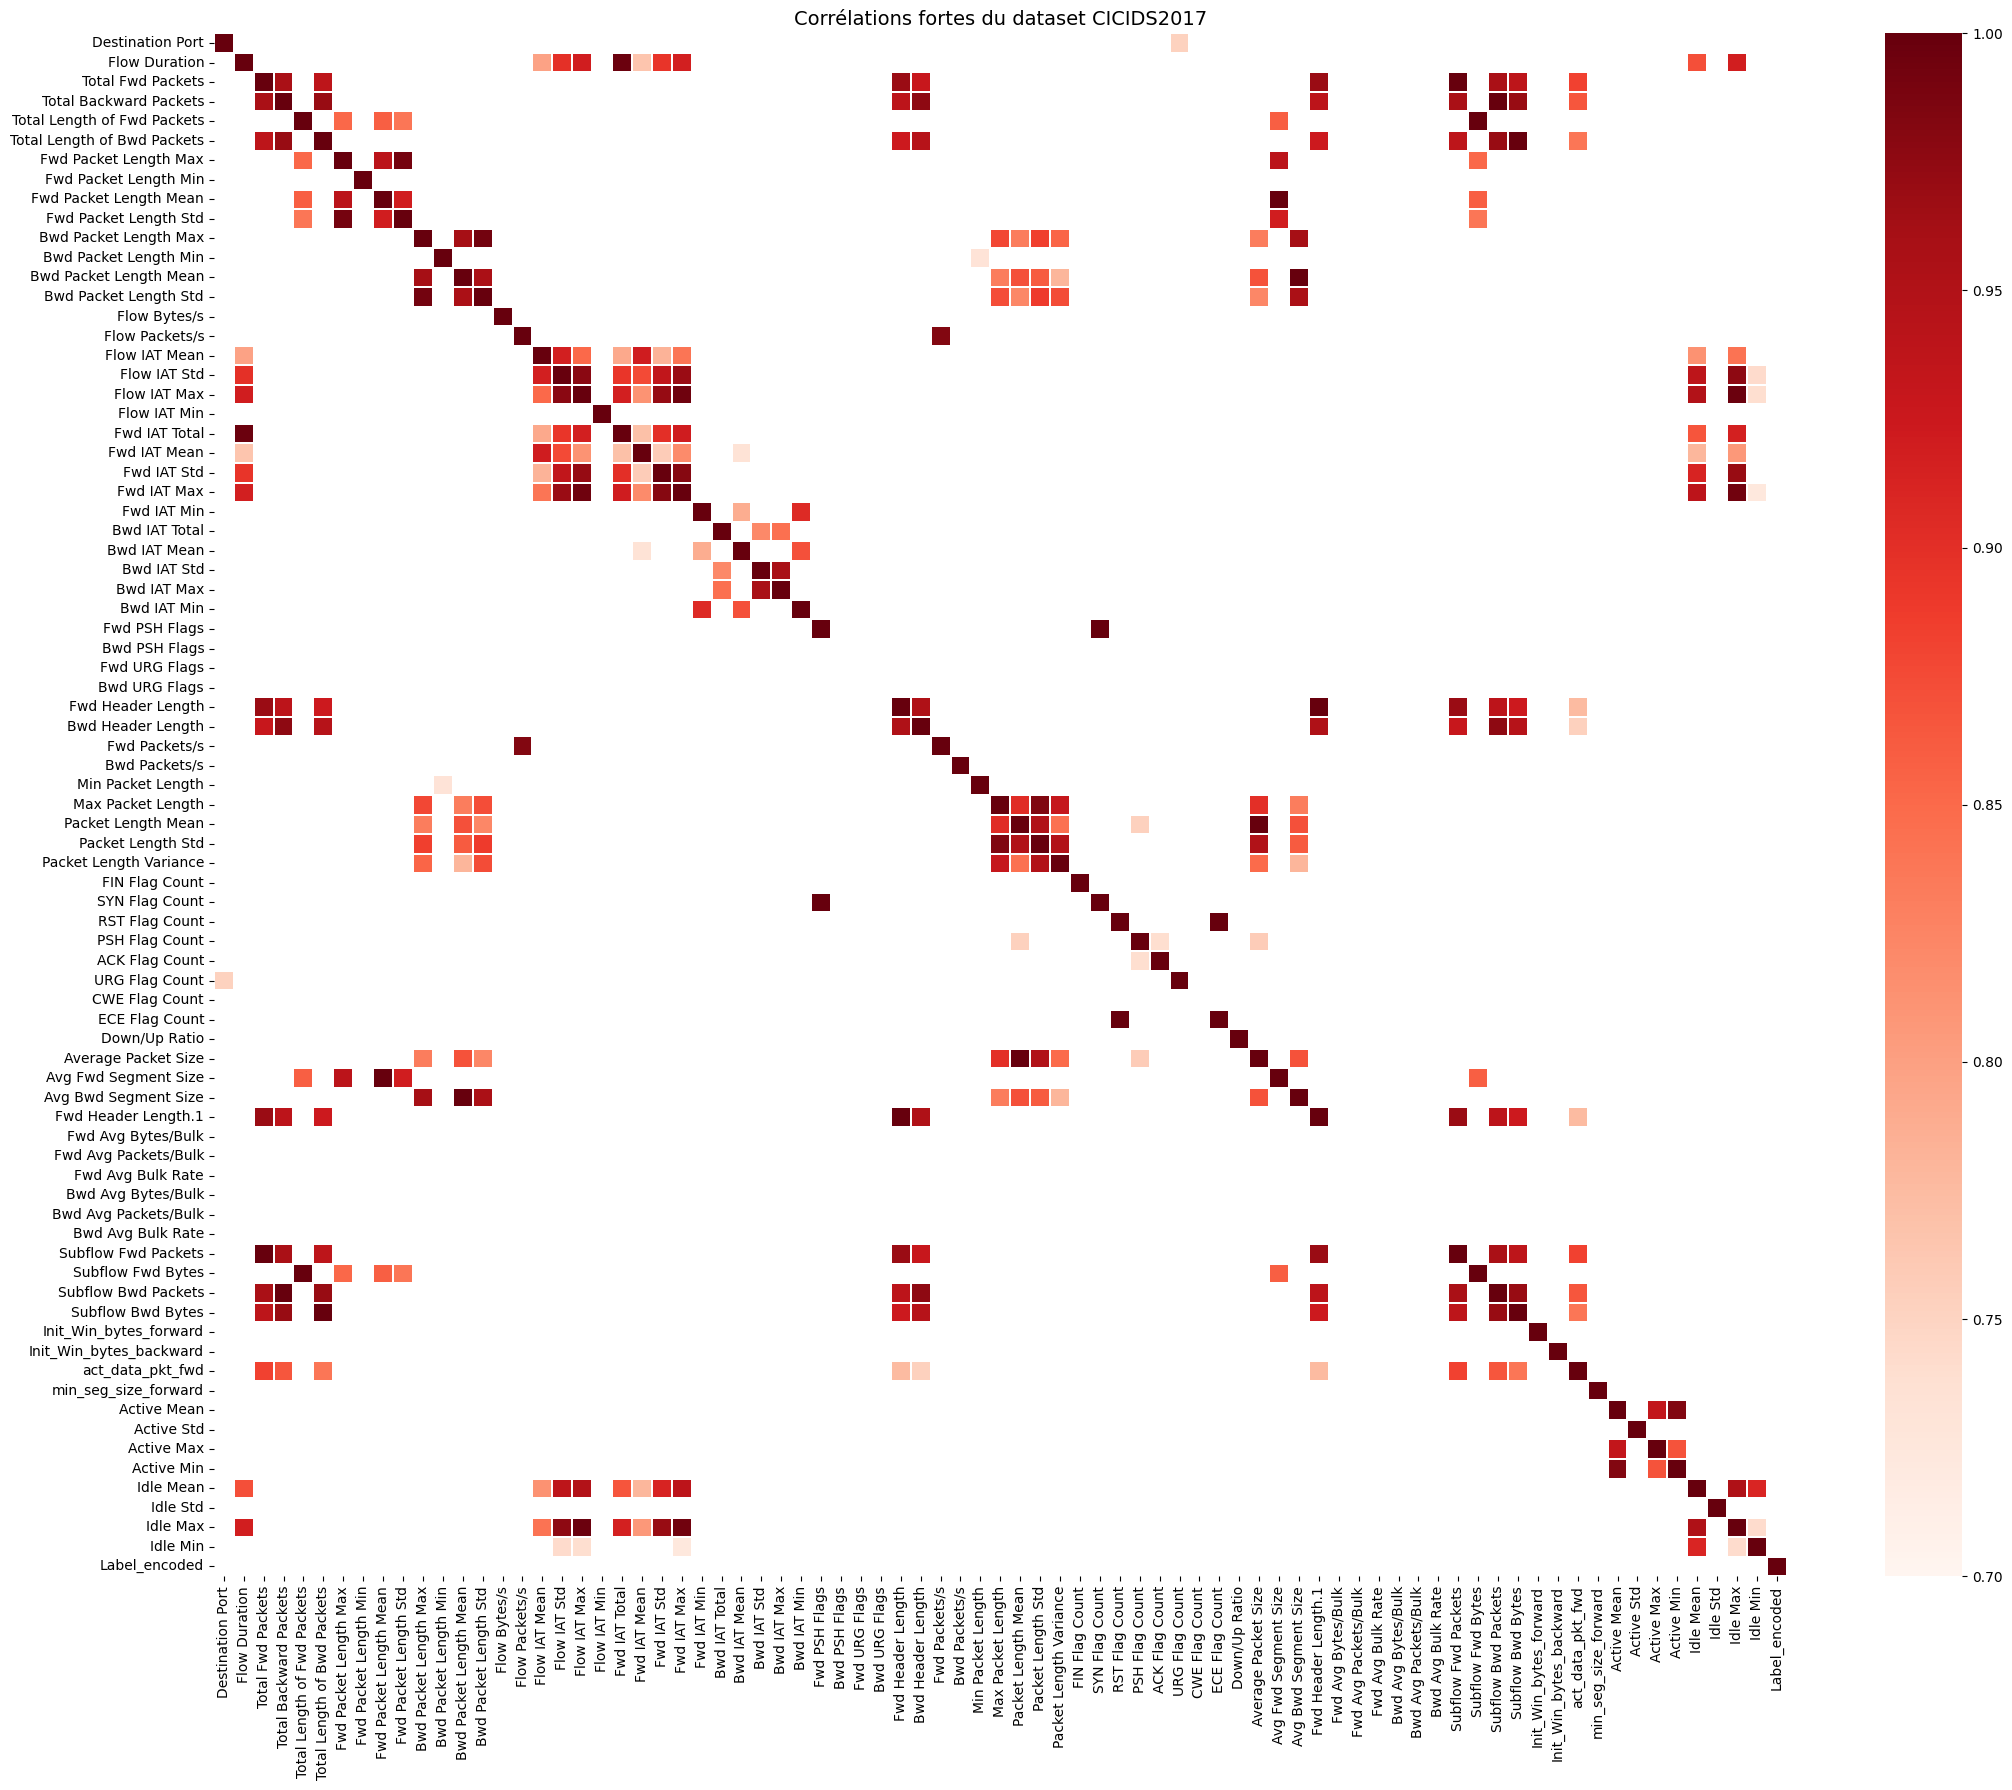

In [8]:
corr_cicids = df_cicids[features_cicids].corr().abs()
masque = corr_cicids < 0.7 # on masque pour cacher les corrélations faibles
plt.figure(figsize=(22, 18))
sns.heatmap(corr_cicids, mask=masque,         
            cmap='Reds',         # rouge = forte corrélation
            vmin=0.7, vmax=1.0,  # échelle de 0.7 à 1
            linewidths=0.1,
            annot=False)         # pas de chiffres car trop de colonnes
plt.title('Corrélations fortes du dataset CICIDS2017', fontsize=14)
plt.tight_layout()
plt.savefig('../Data/corr_cicids.png', dpi=100)
plt.show()

La matrice de corrélation du dataset CICIDS2017 met en évidence plusieurs groupes de features qui mesurent en réalité la même chose sous des angles différents. On remarque notamment un gros bloc rouge autour des features IAT qui regroupent Flow IAT, Fwd IAT et Bwd IAT ainsi toutes ces colonnes mesurent le temps entre les paquets donc elles se répètent inutilement. On voit la même chose avec les features de taille de paquets comme Packet Length Mean, Std, Variance et Max qui sont toutes très corrélées entre elles. Le bloc Subflow est aussi très redondant car Subflow Fwd Packets et Subflow Fwd Bytes donnent quasiment la même information que les features de paquets globaux.
Les zones blanches sur la matrice représentent les features indépendantes donc ce sont celles qui apportent une vraie information et que l'on va garder pour la modélisation. 

### 1.3 Suppression des features redondantes

Maintenant on va supprimer les features dont la corrélation est supérieure à 0.95 car elles apportent la même information.

In [11]:
seuil = 0.95 #on supprime les features corrélées à plus de 95%
features_supprimer = set()
#pour chaque paire de features si  la corrélation est supérieure au seuil on supprime la 2ème paire
for i in range(len(corr_cicids.columns)):
    for j in range(i + 1, len(corr_cicids.columns)):
        if corr_cicids.iloc[i, j] > seuil:
            features_supprimer.add(corr_cicids.columns[j])

print(f"Nombre de features supprimées : {len(features_supprimer)}")
df_cicids_reduit = df_cicids[features_cicids].drop(columns=features_supprimer) #on supprime les features redondantes
print(f"Avant : {len(features_cicids)} features puis après : {df_cicids_reduit.shape[1]} features")

Nombre de features supprimées : 26
Avant : 79 features puis après : 53 features


### 1.4 PCA

PCA est un algorithme de machine learning sans supervision qui tente de réduire la dimensionnalité (nombre de fonctions) au sein d'un jeu de données tout en conservant autant d'informations que possible. Ensuite on affiche un nuage de points où chaque point est une connexion, colorié en bleu si c'est normal et en rouge si c'est une attaque. Si les deux couleurs forment des groupes bien séparés sur le graphique, ça veut dire que nos features permettent de distinguer facilement le trafic normal du trafic malveillant 

In [13]:
X_cicids = df_cicids_reduit.fillna(0).replace([np.inf, -np.inf], 0) #on remplace les valeurs manquantes et infinies par 0
y_cicids = (df_cicids['Label'] != 'BENIGN').astype(int) #label pour 0 signifie normal et 1 pour une attaque
X_cicids_scaled = StandardScaler().fit_transform(X_cicids) #normalisation permet de mettre toutes les features à la même échelle
X_pca = PCA(n_components=2).fit_transform(X_cicids_scaled) # PCA

pca = PCA(n_components=2).fit(X_cicids_scaled) #pourcentage d'information conservée après compression
print(f"Information conservée : {pca.explained_variance_ratio_.sum():.2%}")
print(f"La 1ère colonne PCA conserve {pca.explained_variance_ratio_[0]:.2%} d'information ")
print(f"La 2nd colonne PCA conserve {pca.explained_variance_ratio_[1]:.2%} d'information")

Information conservée : 32.20%
La 1ère colonne PCA conserve 19.32% d'information 
La 2nd colonne PCA conserve 12.88% d'information


Dans ce dataset l'information conservée est de seulement 32% avec 2 composantes où la 1ère colonne conserve 19% et la 2nd seulement 13%. Ce résultat est assez faible et s'explique par la nature du dataset qui a beaucoup de colonnes très variées qui décrivent des aspects très différents du trafic réseau, donc il est impossible de bien les résumer en seulement 2 dimensions. 

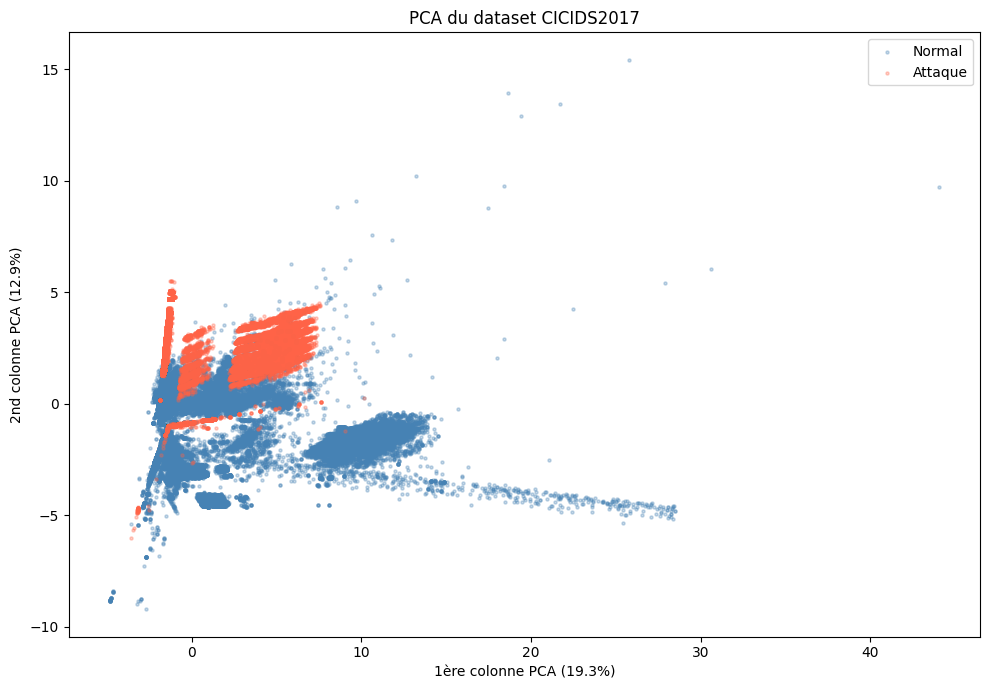

In [16]:
#visualisation de la PCA où bleu signifie normal et rouge une attaque
plt.figure(figsize=(10, 7))
for classe, couleur, label in [(0, 'steelblue', 'Normal'), (1, 'tomato', 'Attaque')]:
    mask = y_cicids == classe
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=couleur, label=label, alpha=0.3, s=5)
plt.xlabel(f'1ère colonne PCA ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'2nd colonne PCA ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('PCA du dataset CICIDS2017')
plt.legend()
plt.tight_layout()
plt.savefig('../Data/pca_cicids.png', dpi=100)
plt.show()

Le graphique montre une séparation entre les deux classes où les points rouges (attaques) forment un groupe distinct dans la partie haute-gauche du graphique tandis que les points bleus (trafic normal) s'étendent plutôt vers la droite et en bas. Cette séparation visible signifie que nos features capturent bien les différences entre trafic normal et trafic DDoS. Et la zone de chevauchement au centre montre que certaines connexions sont difficiles à distinguer.


## Dataset 2 : UNSW-NB15

### 2.1 Sélection des features numériques

In [17]:
features_unsw = [f for f in df_unsw.select_dtypes(include=[np.number]).columns if f not in ['Stime', 'Ltime']] #colonnes numériques sans les timestamps
print(f"Nombre de features numériques : {len(features_unsw)}")
print(features_unsw)

Nombre de features numériques : 43
['dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'Sload', 'Dload', 'Spkts', 'Dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len', 'Sjit', 'Djit', 'Sintpkt', 'Dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'Label', 'proto_encoded', 'state_encoded', 'service_encoded', 'attack_cat_encoded']


### 2.2 Matrice de corrélation

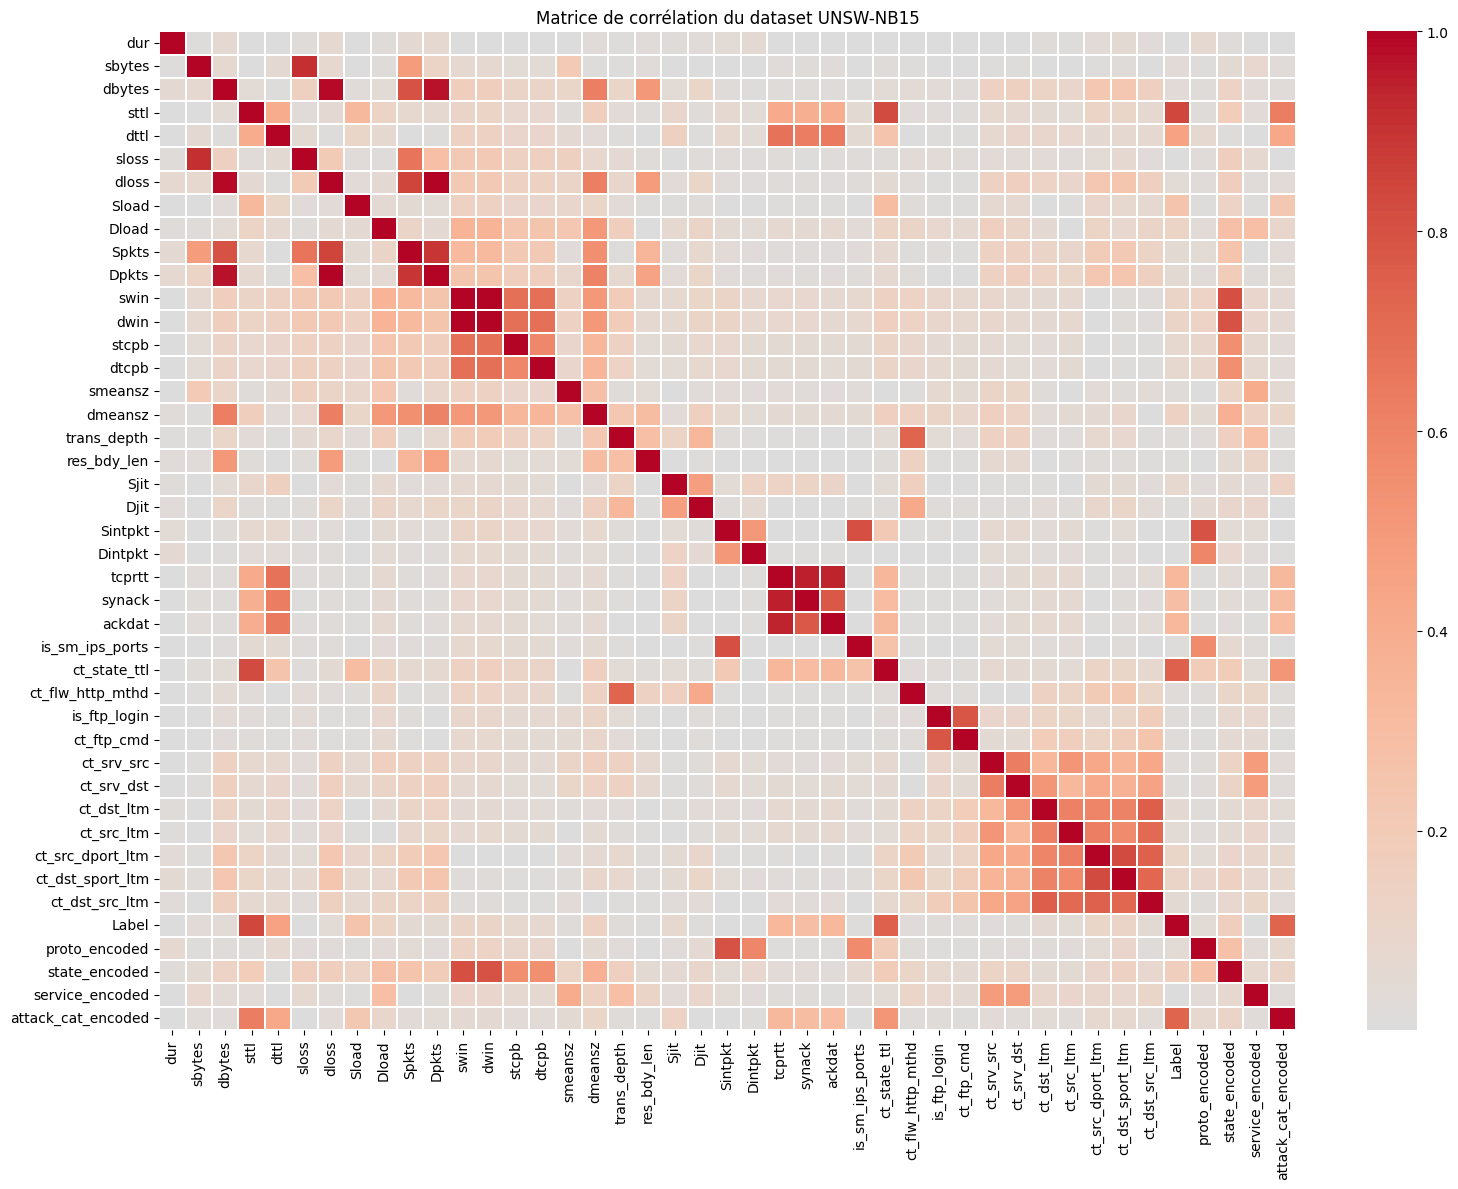

In [18]:
corr_unsw = df_unsw[features_unsw].corr().abs()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_unsw, cmap='coolwarm', center=0, linewidths=0.1)
plt.title('Matrice de corrélation du dataset UNSW-NB15')
plt.tight_layout()
plt.savefig('../Data/corr_unsw.png', dpi=100)
plt.show()

### Matrice de corrélation fortes du dataset UNSW


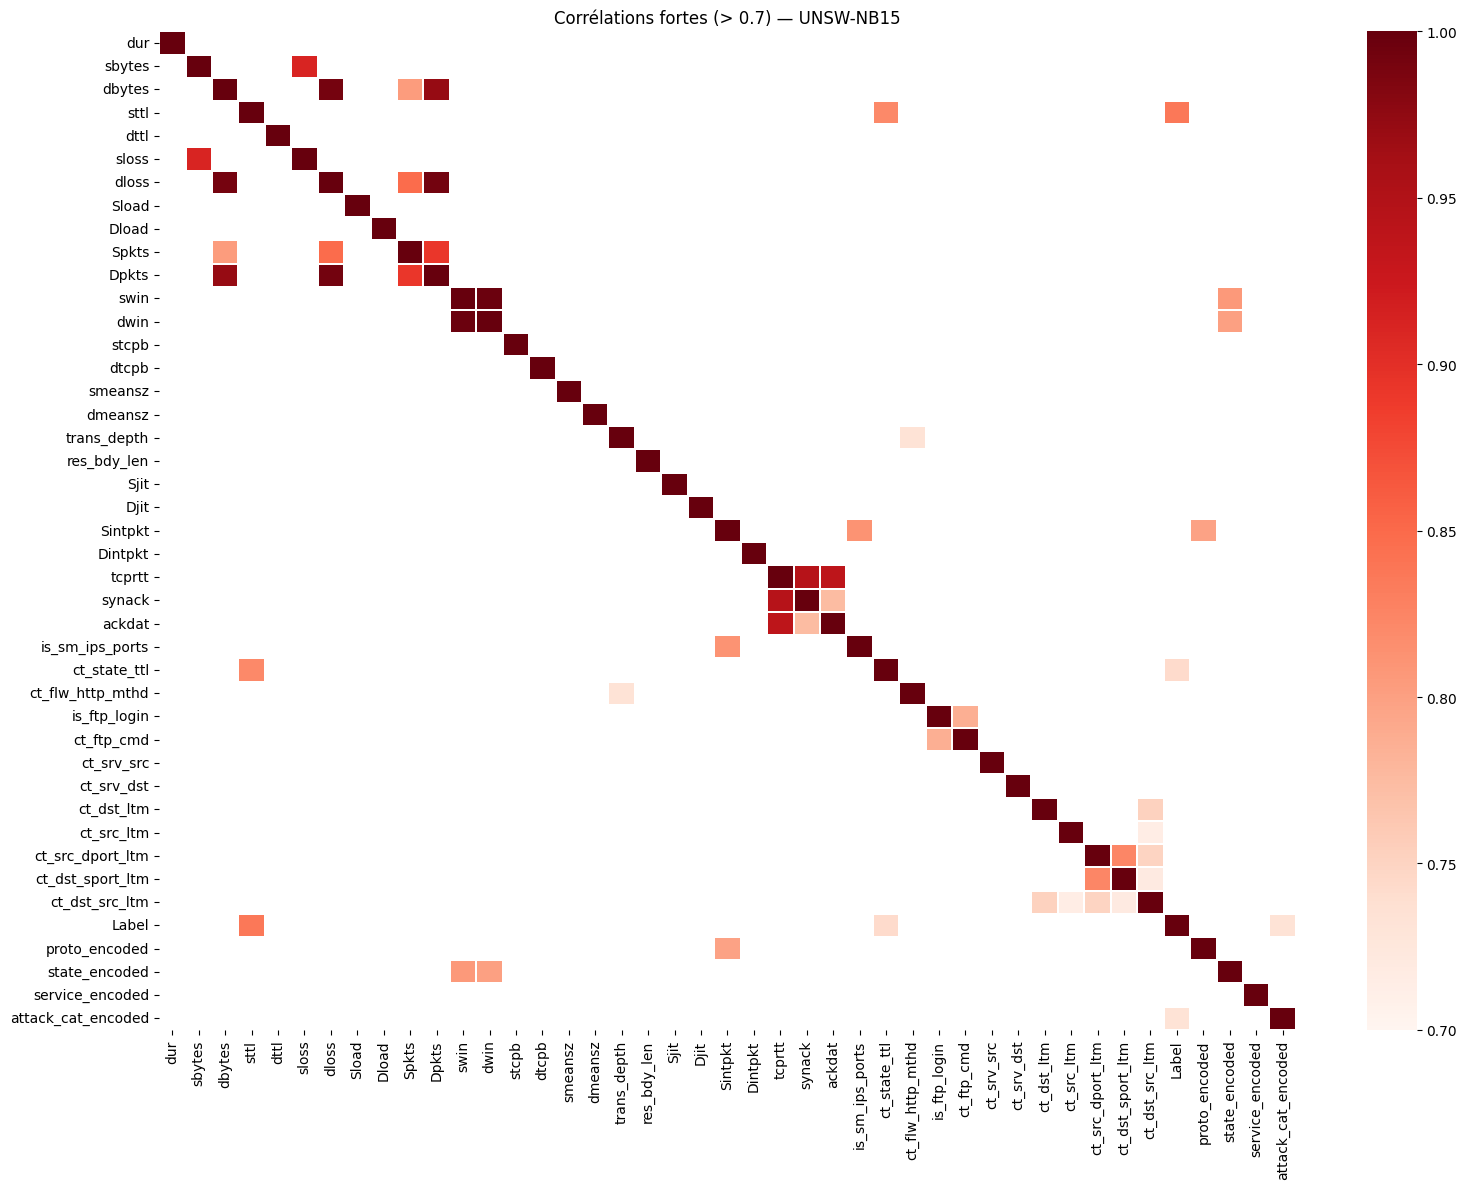

In [19]:
corr_unsw = df_unsw[features_unsw].corr().abs()
plt.figure(figsize=(16, 12))
sns.heatmap(corr_unsw, mask=corr_unsw < 0.7, cmap='Reds',vmin=0.7, vmax=1.0, linewidths=0.1)
plt.title('Corrélations fortes (> 0.7) — UNSW-NB15')
plt.tight_layout()
plt.savefig('../Data/corr_unsw.png', dpi=100)
plt.show()

La matrice de corrélation du dataset UNSW-NB15 est plus facile à lire que celle du dataset CICIDS car le dataset a moins de colonnes. On remarque plusieurs groupes de features qui mesurent la même chose comme par exemple sbytes, dbytes, sloss, dloss, Sload et Dload sont toutes liées au volume de données échangées donc elles se répètent. Même chose pour synack, ackdat et tcprtt qui mesurent tous des délais TCP, ou encore Sjit et Djit qui représentent la gigue dans les deux sens.Les features comme trans_depth, res_bdy_len ou ct_flw_http_mthd sont isolées sur la matrice ce qui veut dire qu'elles n'ont pas de lien fort avec les autres donc ce sont les plus intéressantes à garder car elles apportent une information unique. 

### 2.3 Suppression des features redondantes

In [28]:
seuil = 0.95
features_supprimer_unsw = {corr_unsw.columns[j]
    for i in range(len(corr_unsw.columns))
    for j in range(i + 1, len(corr_unsw.columns))
    if corr_unsw.iloc[i, j] > seuil}
df_unsw_reduit = df_unsw[features_unsw].drop(columns=features_supprimer_unsw) #supprimer features redondantes
print(f"Nombre de features supprimées : {len(features_supprimer_unsw)}")
print(f"Avant : {len(features_unsw)} puis après : {df_unsw_reduit.shape[1]} features")


Nombre de features supprimées : 3
Avant : 43 puis après : 40 features


### 2.4 PCA — Réduction de dimension

In [22]:
X_unsw = df_unsw_reduit.fillna(0).replace([np.inf, -np.inf], 0)
y_unsw = df_unsw['Label']
X_unsw_scaled = StandardScaler().fit_transform(X_unsw)
pca = PCA(n_components=2).fit(X_unsw_scaled)
X_pca_unsw = pca.transform(X_unsw_scaled)
print(f"Information conservée : {pca.explained_variance_ratio_.sum():.2%}")
print(f"1ère colonne de la PCA conserve  {pca.explained_variance_ratio_[0]:.2%} de l'information")
print(f"2nd colonne de la PCA conserve {pca.explained_variance_ratio_[1]:.2%} de l'information")

Information conservée : 24.33%
1ère colonne de la PCA conserve  12.44% de l'information
2nd colonne de la PCA conserve 11.89% de l'information


Ici on ne conserve que 24% d'information ce qui est encore plus faible que le dataset CICIDS. Les deux composantes contribuent de façon quasi égale avec 12.44% pour la 1ère colonne et 11.89% pour la seconde ce qui signifie qu'il n'y a pas une direction dominante qui explique clairement les données. Cela s'explique par la diversité des features du dataset qui couvrent des aspects très différents du trafic réseau comme le volume, timing, flags TCP, compteurs de connexions donc l'information est très dispersée et difficile à résumer en 2 dimensions. 

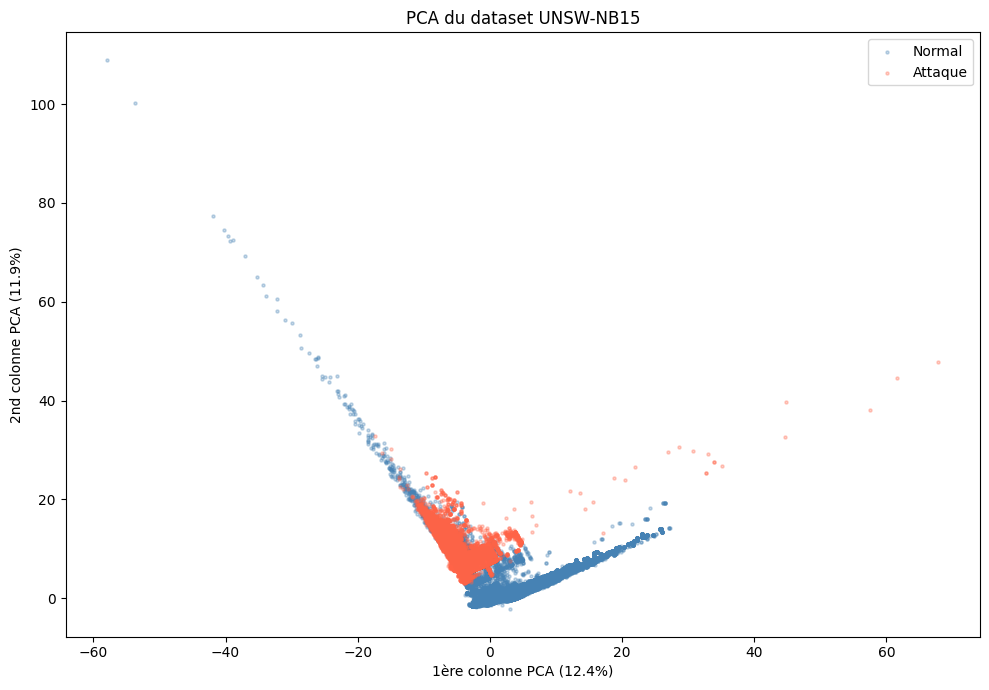

In [23]:
#visualisation PCA où bleu est normal et rouge une attaque
plt.figure(figsize=(10, 7))
for classe, couleur, label in [(0, 'steelblue', 'Normal'), (1, 'tomato', 'Attaque')]:
    mask = y_unsw == classe
    plt.scatter(X_pca_unsw[mask, 0], X_pca_unsw[mask, 1], c=couleur, label=label, alpha=0.3, s=5)

plt.xlabel(f'1ère colonne PCA ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'2nd colonne PCA ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('PCA du dataset UNSW-NB15')
plt.legend()
plt.tight_layout()
plt.savefig('../Data/pca_unsw.png', dpi=100)
plt.show()

On remarque bien que les deux classes se chevauchent beaucoup ce qui confirme que 24% d'information conservée est insuffisant pour bien les séparer. 


## Dataset 3 : Cybersecurity Threat Detection Logs

### 3.1 Sélection des features numériques

In [24]:
features_logs = df_logs.select_dtypes(include=[np.number]).columns.tolist()
print(f"Nombre de features numériques : {len(features_logs)}")
print(features_logs)

Nombre de features numériques : 1
['bytes_transferred']


### 3.2 Matrice de corrélation

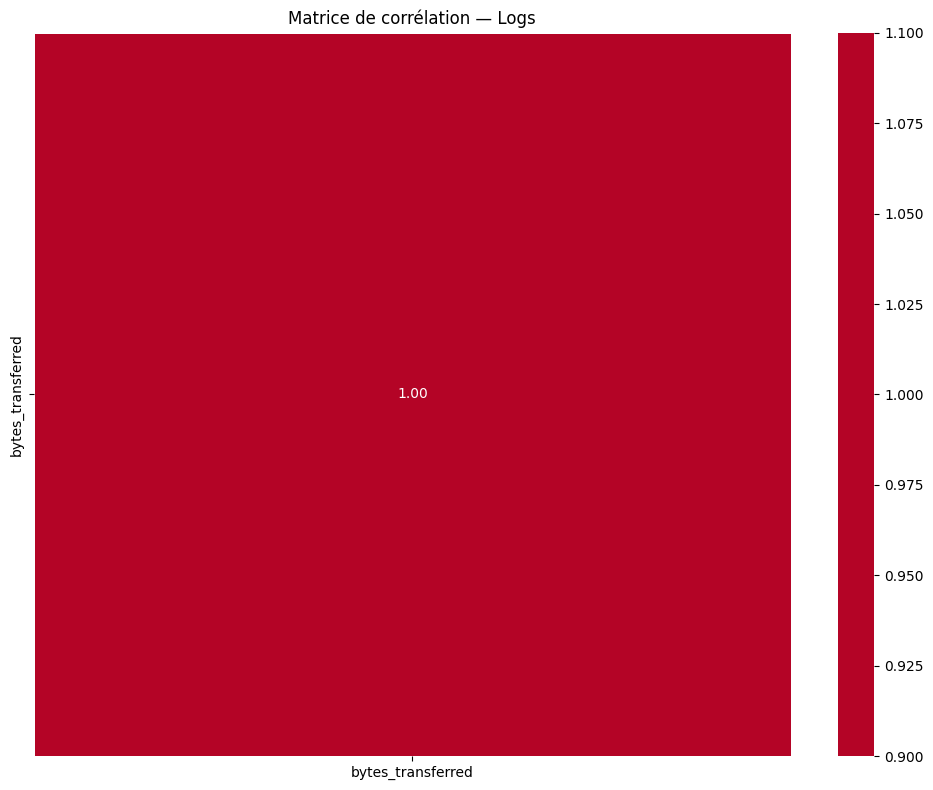

In [25]:
corr_logs = df_logs[features_logs].corr().abs()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_logs, cmap='coolwarm', center=0,annot=True, fmt='.2f', linewidths=0.5) 
plt.title('Matrice de corrélation — Logs')
plt.tight_layout()
plt.savefig('../Data/corr_logs.png', dpi=100)
plt.show()

La matrice est entièrement rouge avec une valeur de 1.00  cela signifie que le dataset Logs n'a qu'une seule colonne numérique qui est bytes_transferred. Il est donc impossible de calculer une matrice de corrélation ou de faire une PCA sur ce dataset car il faut au minimum 2 colonnes numériques.


## Sauvegarde des datasets réduits

In [ ]:
# On ajoute le label aux datasets réduits avant de sauvegarder
df_cicids_reduit['Label']        = df_cicids['Label']
df_unsw_reduit['Label']          = df_unsw['Label']


df_cicids_reduit.to_csv('../Data/cicids_selected.csv', index=False)
df_unsw_reduit.to_csv('../Data/unsw_selected.csv',index=False)


## Bilan global
Le dataset CICIDS2017 possède initialement 79 features, puis on supprime 26 features ainsi il n'en reste que 53. Après avoir exécuté l'algortihme PCA seulement 32.20% de l'information est conservée dont 19.32% conservé par la 1ère colonne et 12.88% de la 2nd.


Le dataset UNSW-NB15 possède initialement 43 features, puis on supprime 3 features ainsi il n'en reste que 40. Après avoir exécuté l'algortihme PCA seulement 24.33% de l'information est conservée dont 12.44%  conservé par la 1ère colonne et  11.89%% de la 2nd.


Le dataset Logs ne contient qu'une seule colonne numérique (bytes_transferred) ce qui rend la PCA et la corrélation inutilisables sans encodage préalable.